Área estimada por Monte Carlo (normal): 8.376874
Área real (integral definida): 8.381004


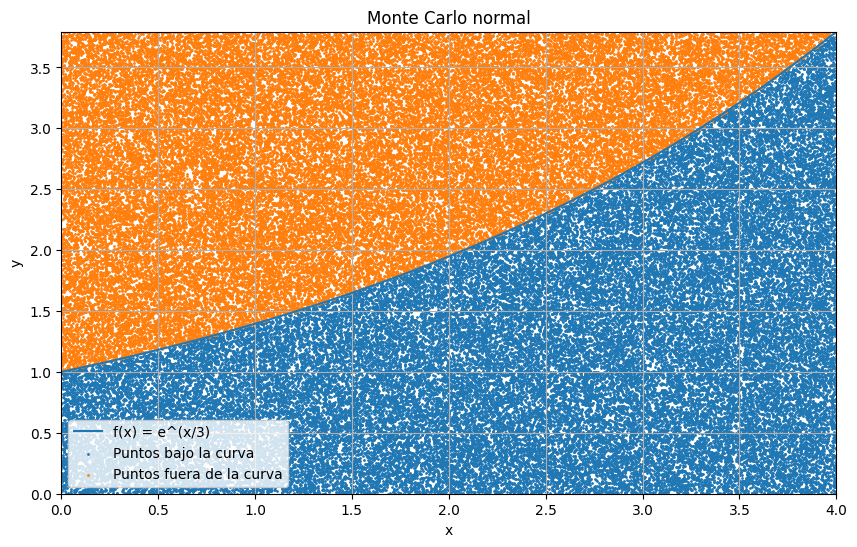

In [3]:
#Aproximaciones del área bajo la curva con el método normal, multihilos y multiprocesos
# Método normal (Monte carlo)
import math
import random
import time
import matplotlib.pyplot as plt

# Definición de la función
def f(x):
    return math.exp(x / 3)

# Intervalo en x
a = 0
b = 4
y_max = f(b)

# Valor real de la integral
area_real = 3 * (math.exp(4/3) - 1)

# Cantidad de puntos, elegir una cantidad considerable de puntos
n_puntos = 100000

#Listas, nos servirán para poder graficar
x_dentro = []
y_dentro = []
x_fuera = []
y_fuera = []

# Contador de puntos bajo la curva
puntos_bajo = 0
inicio = time.time()

# Método Monte Carlo normal
for _ in range(n_puntos):
    x = random.uniform(a, b)
    y = random.uniform(0, y_max)

    if y <= f(x):
        puntos_bajo += 1
        x_dentro.append(x)
        y_dentro.append(y)
    else:
         x_fuera.append(x)
         y_fuera.append(y)


area_rectangulo = (b - a) * y_max
area_estimado = (puntos_bajo / n_puntos) * area_rectangulo
fin = time.time()
tiempo_normal = fin - inicio

print(f"Área estimada por Monte Carlo (normal): {area_estimado:.6f}")
print(f"Área real (integral definida): {area_real:.6f}")

# Gráfica
x_curva = [a + i * (b - a) / 500 for i in range(501)]
y_curva = [f(x) for x in x_curva]

plt.figure(figsize=(10, 6))
plt.plot(x_curva, y_curva, label="f(x) = e^(x/3)")
plt.scatter(x_dentro, y_dentro, s=1, label="Puntos bajo la curva")
plt.scatter(x_fuera, y_fuera, s=1, label="Puntos fuera de la curva")
plt.xlim(a, b)
plt.ylim(0, y_max)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Monte Carlo normal")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Metodo multihilos
import math
import random
import time
from concurrent.futures import ThreadPoolExecutor

# Definición de la función
def f(x):
    return math.exp(x / 3)

# Intervalo en x
a = 0
b = 4
y_max = f(b)

# Cantidad total de puntos
n_puntos = 100000

# Número de hilos
n_hilos = 4

# Trabajo que hará cada hilo
def contar_puntos_hilo(cantidad):
    contador = 0
    for _ in range(cantidad):
        x = random.uniform(a, b)
        y = random.uniform(0, y_max)

        if y <= f(x):
            contador += 1
    return contador

# Reparto de puntos
puntos_por_hilo = [n_puntos // n_hilos] * n_hilos
puntos_por_hilo[-1] += n_puntos % n_hilos

# Tiempo inicial
inicio = time.time()

with ThreadPoolExecutor(max_workers=n_hilos) as executor:
    resultados = list(executor.map(contar_puntos_hilo, puntos_por_hilo))

puntos_bajo = sum(resultados)
area_rectangulo = (b - a) * y_max

# Estimación del área
area_estimado = (puntos_bajo / n_puntos) * area_rectangulo

# Tiempo final
fin = time.time()
tiempo_hilos = fin - inicio

print(f"Área estimada por Multihilos: {area_estimado:.6f}")
print(f"Tiempo de ejecución: {tiempo_hilos:.6f} segundos")

Área estimada por Multihilos: 8.407527
Tiempo de ejecución: 0.063339 segundos


In [8]:
# Multiprocesos
import math
import random
import time
from concurrent.futures import ProcessPoolExecutor

# Definición de la función
def f(x):
    return math.exp(x / 3)

# Intervalo en x
a = 0
b = 4
y_max = f(b)

# Cantidad total de puntos
n_puntos = 100000

# Número de procesos
n_procesos = 4

# Trabajo que hará cada proceso
def contar_puntos_proceso(cantidad):
    contador = 0
    generador = random.Random()

    for _ in range(cantidad):
        x = generador.uniform(a, b)
        y = generador.uniform(0, y_max)

        if y <= f(x):
            contador += 1
    return contador

# Reparto de puntos
puntos_por_proceso = [n_puntos // n_procesos] * n_procesos
puntos_por_proceso[-1] += n_puntos % n_procesos

if __name__ == "__main__":
    inicio = time.time()

    with ProcessPoolExecutor(max_workers=n_procesos) as executor:
        resultados = list(executor.map(contar_puntos_proceso, puntos_por_proceso))

    puntos_bajo = sum(resultados)

    area_rectangulo = (b - a) * y_max
    area_estimado = (puntos_bajo / n_puntos) * area_rectangulo

    fin = time.time()
    tiempo_procesos = fin - inicio

    print(f"Área estimada por Multiprocesos: {area_estimado:.6f}")
    print(f"Tiempo de ejecución: {tiempo_procesos:.6f} segundos")

Área estimada por Multiprocesos: 8.390683
Tiempo de ejecución: 0.112469 segundos


In [11]:
print("Comparación de tiempos de ejecución")
print(f"Método normal:         {tiempo_normal:.6f} segundos")
print(f"Método multihilos:     {tiempo_hilos:.6f} segundos")
print(f"Método multiprocesos:  {tiempo_procesos:.6f} segundos")

Comparación de tiempos de ejecución
Método normal:         0.176722 segundos
Método multihilos:     0.063339 segundos
Método multiprocesos:  0.112469 segundos
